In [1]:
!pip install optuna

import os
import gc
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import optuna
import time

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.utils import resample

# ==========================================
# CONFIGURAÇÕES
# ==========================================
SEED = 42
np.random.seed(SEED)
DATASET_PATH = "/content/drive/MyDrive/2026/ic/npz_files/utd_mhad_v2.npz"


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 8.0 MB/s eta 0:00:00


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# ==========================================
# 1. CARREGAMENTO & PREPARAÇÃO
# ==========================================
def load_data(path):
    print(f"Carregando dataset: {path}...")
    try:
        data = np.load(path, allow_pickle=True)
        X_train = data['X_train']
        y_train = data['y_train']
        X_val = data['X_val']
        y_val = data['y_val']
        X_test = data['X_test']
        y_test = data['y_test']

        print(f"   Dados Carregados:")
        print(f"   Treino: {X_train.shape} | Val: {X_val.shape} | Teste: {X_test.shape}")
        return X_train, y_train, X_val, y_val, X_test, y_test
    except FileNotFoundError:
        print("Erro: Arquivo .npz não encontrado.")
        return None, None, None, None, None, None

def prep_data_raw(X):
    """
    Cenário 1 & 3: RAW DATA (Flatten)
    (N, T, F) -> (N, T*F)
    """
    N, T, F = X.shape
    return X.reshape(N, T * F)

def prep_data_features(X):
    """
    Cenário 2 & 4: FEATURE ENGINEERING (Statistical)
    """
    # Estatísticas ao longo do tempo (eixo 1)
    feat_mean = np.mean(X, axis=1)
    feat_std  = np.std(X, axis=1)
    feat_max  = np.max(X, axis=1)
    feat_min  = np.min(X, axis=1)

    # Concatena as estatísticas
    return np.hstack([feat_mean, feat_std, feat_max, feat_min])


In [4]:
# ==========================================
# 2. OPTUNA (OTIMIZAÇÃO)
# ==========================================
def run_optuna(X_tr, y_tr, X_va, y_va, n_trials=50):
    print(f"   [Optuna] Iniciando otimização ({n_trials} trials)...")

    def objective(trial):
        n_estimators = trial.suggest_int('n_estimators', 100, 1000)

        use_max_depth = trial.suggest_categorical('use_max_depth', [True, False])
        max_depth = trial.suggest_int('max_depth', 10, 50) if use_max_depth else None

        min_samples_split = trial.suggest_int('min_samples_split', 2, 20)
        min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 10)

        max_features = trial.suggest_categorical('max_features', ['sqrt', 'log2', None])
        class_weight = trial.suggest_categorical('class_weight', [None, 'balanced', 'balanced_subsample'])

        model = RandomForestClassifier(
            n_estimators=n_estimators,
            max_depth=max_depth,
            min_samples_split=min_samples_split,
            min_samples_leaf=min_samples_leaf,
            max_features=max_features,
            class_weight=class_weight,
            n_jobs=-1,
            random_state=SEED
        )

        model.fit(X_tr, y_tr)
        preds = model.predict(X_va)
        return f1_score(y_va, preds, average='macro')

    optuna.logging.set_verbosity(optuna.logging.WARNING)

    # Amostrador com semente fixa para reprodutibilidade no Optuna
    sampler = optuna.samplers.TPESampler(seed=SEED)
    study = optuna.create_study(direction='maximize', sampler=sampler)
    study.optimize(objective, n_trials=n_trials)

    print(f"   [Optuna] Melhores Params: {study.best_params}")

    # Tratar os melhores parâmetros para remover o 'use_max_depth' que é auxiliar
    best_params = study.best_params.copy()
    if 'use_max_depth' in best_params:
        if not best_params['use_max_depth']:
            best_params['max_depth'] = None
        del best_params['use_max_depth']

    return best_params


In [5]:
# ==========================================
# 3. AVALIAÇÃO (BOOTSTRAP)
# ==========================================
def bootstrap_eval(model, X_test, y_test, n_iterations=1000):
    scores = []
    n_size = len(y_test)

    for i in range(n_iterations):
        # Amostragem com reposição
        X_sample, y_sample = resample(X_test, y_test, n_samples=n_size, random_state=i)

        pred = model.predict(X_sample)
        score = f1_score(y_sample, pred, average='macro')
        scores.append(score)

    alpha = 0.95
    p = ((1.0 - alpha) / 2.0) * 100
    lower = np.percentile(scores, p)
    upper = np.percentile(scores, 100 - p)
    mean_score = np.mean(scores)

    return mean_score, lower, upper


Carregando dados...
Carregando dataset: /content/drive/MyDrive/2026/ic/npz_files/utd_mhad_v2.npz...
   Dados Carregados:
   Treino: (457, 125, 66) | Val: (145, 125, 66) | Teste: (623, 125, 66)

>>> EXECUTANDO: 1. Raw + Default <<<
   [F1] Boot: 0.4892 (0.4504 - 0.5249)
   [Acc] Boot: 0.4981 (0.4607 - 0.5393)

>>> EXECUTANDO: 2. Features + Default <<<
   [F1] Boot: 0.7050 (0.6713 - 0.7383)
   [Acc] Boot: 0.7289 (0.6918 - 0.7640)

>>> EXECUTANDO: 3. Raw + Optuna <<<
   [Optuna] Iniciando otimização (50 trials)...
   [Optuna] Melhores Params: {'n_estimators': 103, 'use_max_depth': False, 'min_samples_split': 16, 'min_samples_leaf': 3, 'max_features': None, 'class_weight': None}
   [F1] Boot: 0.4385 (0.3996 - 0.4772)
   [Acc] Boot: 0.4459 (0.4061 - 0.4864)

>>> EXECUTANDO: 4. Features + Optuna <<<
   [Optuna] Iniciando otimização (50 trials)...
   [Optuna] Melhores Params: {'n_estimators': 279, 'use_max_depth': False, 'min_samples_split': 15, 'min_samples_leaf': 8, 'max_features': 'sqrt', 

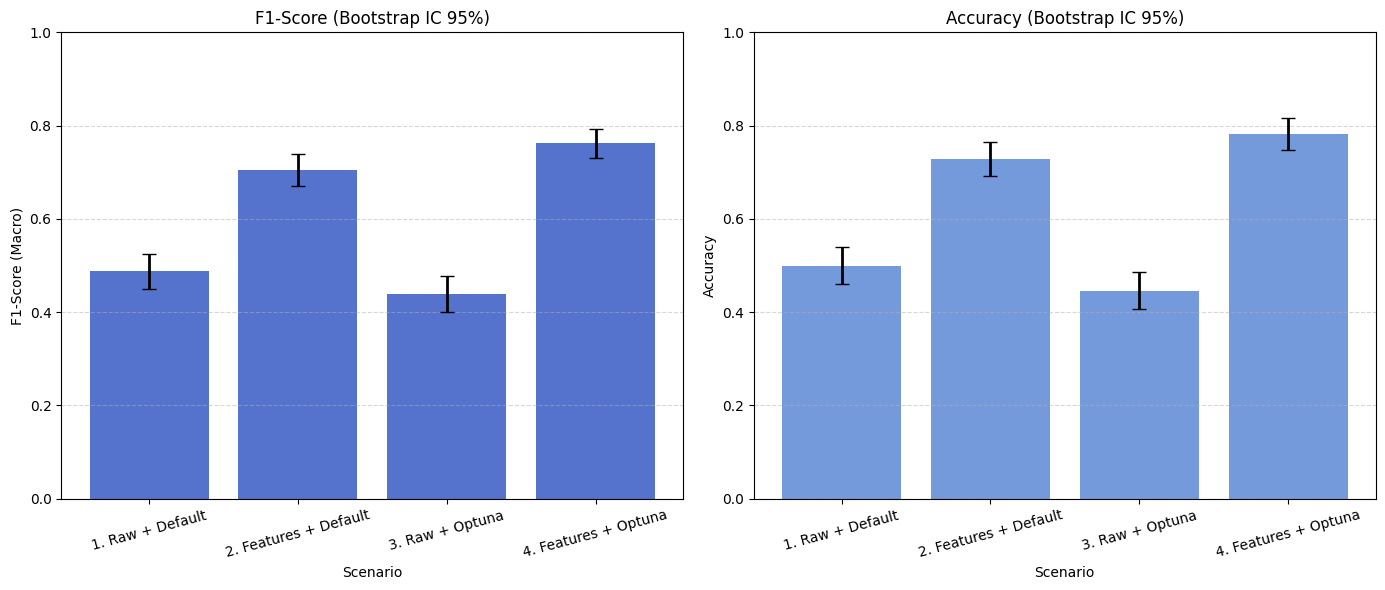

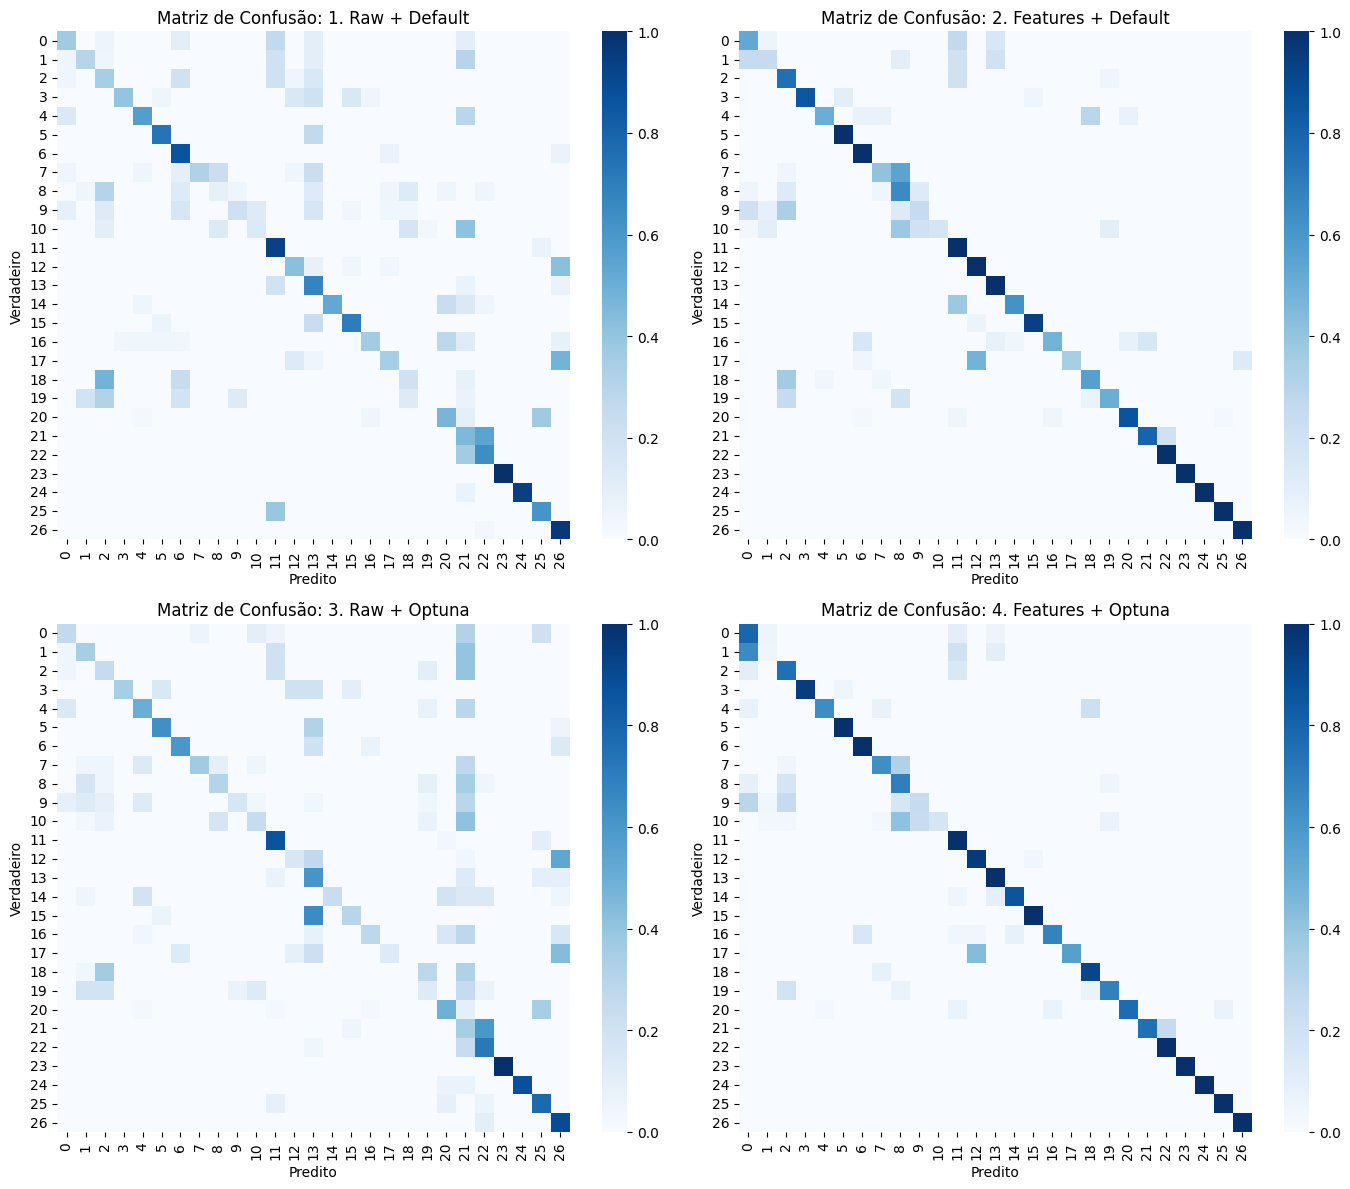

In [6]:
# ==============================================================================
# 0. GARANTIA DE CARGA DOS DADOS
# ==============================================================================
# Verifica se as variáveis existem, senão carrega
if 'X_train_full' not in locals() or X_train_full is None:
    print("Carregando dados...")
    X_train_full, y_train_full, X_val_full, y_val_full, X_test_full, y_test_full = load_data(DATASET_PATH)

# ==============================================================================
# 1. FUNÇÃO DE AVALIAÇÃO (Bootstrap F1 + Accuracy)
# ==============================================================================
def bootstrap_eval(model, X_test, y_test, n_iterations=1000):
    f1_scores = []
    acc_scores = []
    n_size = len(y_test)

    for i in range(n_iterations):
        # Amostragem com reposição
        X_sample, y_sample = resample(X_test, y_test, n_samples=n_size, random_state=i)
        pred = model.predict(X_sample)
        f1_scores.append(f1_score(y_sample, pred, average='macro'))
        acc_scores.append(accuracy_score(y_sample, pred))

    return (
        np.mean(f1_scores), np.percentile(f1_scores, 2.5), np.percentile(f1_scores, 97.5),
        np.mean(acc_scores), np.percentile(acc_scores, 2.5), np.percentile(acc_scores, 97.5)
    )

# ==============================================================================
# 2. DEFINIÇÃO DOS CENÁRIOS E EXECUÇÃO
# ==============================================================================
scenarios = [
    ("1. Raw + Default", prep_data_raw, False),
    ("2. Features + Default", prep_data_features, False),
    ("3. Raw + Optuna", prep_data_raw, True),
    ("4. Features + Optuna", prep_data_features, True)
]

results = []

for name, prep_func, use_optuna in scenarios:
    print(f"\n>>> EXECUTANDO: {name} <<<")
    start_time = time.time()

    # A. Preparação usando as 3 partições
    X_tr = prep_func(X_train_full)
    X_va = prep_func(X_val_full)
    X_te = prep_func(X_test_full)

    # B. Modelo
    if use_optuna:
        best_params = run_optuna(X_tr, y_train_full, X_va, y_val_full, n_trials=50)
        model = RandomForestClassifier(**best_params, n_jobs=-1, random_state=SEED)
        model.fit(X_tr, y_train_full)
    else:
        model = RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=SEED)
        model.fit(X_tr, y_train_full)

    # C. Validação (Test Set) para Matriz de Confusão (NORMALIZADA)
    y_pred = model.predict(X_te)
    cm = confusion_matrix(y_test_full, y_pred, normalize='true')

    # D. Bootstrap no Test Set
    b_f1_mean, b_f1_low, b_f1_high, b_acc_mean, b_acc_low, b_acc_high = bootstrap_eval(model, X_te, y_test_full, n_iterations=1000)

    elapsed = time.time() - start_time
    print(f"   [F1] Boot: {b_f1_mean:.4f} ({b_f1_low:.4f} - {b_f1_high:.4f})")
    print(f"   [Acc] Boot: {b_acc_mean:.4f} ({b_acc_low:.4f} - {b_acc_high:.4f})")

    results.append({
        "Scenario": name,
        "Boot_F1_Mean": b_f1_mean,
        "Boot_F1_Lower": b_f1_low,
        "Boot_F1_Upper": b_f1_high,
        "Boot_Acc_Mean": b_acc_mean,
        "Boot_Acc_Lower": b_acc_low,
        "Boot_Acc_Upper": b_acc_high,
        "Time_Sec": elapsed,
        "CM": cm
    })

    del X_tr, X_va, X_te, model
    gc.collect()

# ==============================================================================
# 3. RELATÓRIO E GRÁFICOS
# ==============================================================================
df_res = pd.DataFrame(results)

print("\n\n=== RELATÓRIO FINAL: RANDOM FOREST (UTD-MHAD) ===")
display_cols = ['Scenario', 'Boot_F1_Mean', 'Boot_F1_Lower', 'Boot_F1_Upper', 'Boot_Acc_Mean', 'Boot_Acc_Lower', 'Boot_Acc_Upper', 'Time_Sec']
print(df_res[display_cols].to_string(index=False))

# -- Gráficos de Barras (Histogramas) --
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# F1-Score
yerr_f1 = [
    df_res['Boot_F1_Mean'] - df_res['Boot_F1_Lower'],
    df_res['Boot_F1_Upper'] - df_res['Boot_F1_Mean']
]
sns.barplot(data=df_res, x='Scenario', y='Boot_F1_Mean', color='royalblue', ax=ax[0])
ax[0].errorbar(x=range(len(df_res)), y=df_res['Boot_F1_Mean'], yerr=yerr_f1, fmt='none', c='black', linewidth=2, capsize=5)
ax[0].set_title("F1-Score (Bootstrap IC 95%)")
ax[0].set_ylabel("F1-Score (Macro)")
ax[0].set_ylim(0.0, 1.0)
ax[0].grid(axis='y', linestyle='--', alpha=0.5)
ax[0].tick_params(axis='x', rotation=15)

# Acurácia
yerr_acc = [
    df_res['Boot_Acc_Mean'] - df_res['Boot_Acc_Lower'],
    df_res['Boot_Acc_Upper'] - df_res['Boot_Acc_Mean']
]
sns.barplot(data=df_res, x='Scenario', y='Boot_Acc_Mean', color='cornflowerblue', ax=ax[1])
ax[1].errorbar(x=range(len(df_res)), y=df_res['Boot_Acc_Mean'], yerr=yerr_acc, fmt='none', c='black', linewidth=2, capsize=5)
ax[1].set_title("Accuracy (Bootstrap IC 95%)")
ax[1].set_ylabel("Accuracy")
ax[1].set_ylim(0.0, 1.0)
ax[1].grid(axis='y', linestyle='--', alpha=0.5)
ax[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

# -- Matrizes de Confusão --
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for idx, row in df_res.iterrows():
    sns.heatmap(row['CM'], annot=False, cmap='Blues', ax=axes[idx], cbar=True, vmin=0, vmax=1)
    axes[idx].set_title(f"Matriz de Confusão: {row['Scenario']}")
    axes[idx].set_xlabel("Predito")
    axes[idx].set_ylabel("Verdadeiro")

plt.tight_layout()
plt.show()
